# Pygformula pipeline with features identiying L

In [1]:
import numpy as np
import pygformula
from pygformula import ParametricGformula
from pygformula.interventions import static
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#%matplotlib ipympl

# Load MIMIC data

In [2]:
mimicdata = pd.read_parquet('../Dataset/mimic-iv/from_pipeline/ltm_grided_clipped_A_D_Z_Y_SelfPipeline.parquet')

In [3]:
mimicdata.shape

(701079, 40)

In [4]:
mimicdata.columns

Index(['stay_id', 'grid_end', 'vent_mode__hours_since_last__last_12h',
       'temperature__mean__last_12h', 'heart_rate__mean__last_12h',
       'arterial_blood_pressure_mean__mean__last_12h',
       'fluid_out_urine__mean__last_12h', 'pco2_arterial__mean__last_12h',
       'respiratory_rate_measured__mean__last_12h',
       'o2_saturation__mean__last_12h', 'po2_arterial__mean__last_12h',
       'bicarbonate_arterial__last__last_12h',
       'activated_partial_thromboplastin_time__last__last_12h',
       'hemoglobin__last__last_12h', 'creatinine__last__last_12h',
       'ureum__last__last_12h', 'lactate__last__last_12h',
       'glasgow_coma_scale_total__last__last_12h', 'fio2__last__last_12h',
       'vent_mode__last__last_12h', 'subject_id', 'raw_age', 'sex',
       'raw_height', 'raw_weight', 'unit_type', 'origin', 'los', 'intime',
       'outtime', 'death_time_from_intime', 'icu_mortality_flag',
       'death_abs_time', 'icu_mortality', 't', 'mortality_after_discharge_30d',
      

In [5]:
mimicdata.rename(columns={"stay_id": "admission_id", "t": "t0", "raw_age":"age", "raw_height":"height", "raw_weight":"weight"}, inplace=True)

In [6]:
# Declaring vent_mode as categorical variable
mimicdata.vent_mode__last__last_12h = mimicdata.vent_mode__last__last_12h.astype("category")
mimicdata.fio2__last__last_12h = mimicdata.fio2__last__last_12h.astype("category")
mimicdata.glasgow_coma_scale_total__last__last_12h = mimicdata.glasgow_coma_scale_total__last__last_12h.astype("category")

# Declare baseline variables and meta variables

In [7]:
#baseline = ['age',
#            'gender',
#            'ethnicity',
#            'insurance'
#            ]
baseline = ["age", 
            "sex", 
            #"height", 
            #"weight", 
            #"unit_type", 
            "origin"]

In [13]:
mimicdata.origin.unique()

array(['Emergency', 'Other', 'Unknown', 'Operating Room', 'Direct Admit'],
      dtype=object)

In [8]:
mimicdata.groupby('admission_id').tail(1)['A'].mean()

np.float64(0.9198701741594835)

# Deaths

In [9]:
obs_data = mimicdata.copy()
last_rows = (
        obs_data.sort_values(['admission_id', 't0'])
          .groupby('admission_id')
          .tail(1)
    )
    
D_mean = last_rows['D'].fillna(0).mean()
Z_mean = last_rows['Z'].fillna(0).mean()
Y_mean = last_rows['Y'].mean()

results = []
label = "MIMIC"
results.append({
    "Strategy": label,
    "Mean D (stay-level)": D_mean,
    "Mean Z (stay-level)": Z_mean,
    "Mean Y (stay-level)": Y_mean
})
summary_table = pd.DataFrame(results)
summary_table

,Strategy,Mean D (stay-level),Mean Z (stay-level),Mean Y (stay-level)
0,MIMIC,0.072451,0.074838,0.147289


In [10]:
mimicdata[['Y', 'D']].drop_duplicates(ignore_index=True)

,Y,D
0,NaN,0.0
1,0.0,NaN
2,1.0,NaN
3,1.0,1.0
4,0.0,0.0


In [11]:
mimicdata.groupby('admission_id').tail(1)[['Y', 'D']].drop_duplicates(ignore_index=True)

,Y,D
0,0.0,NaN
1,1.0,NaN
2,1.0,1.0
3,0.0,0.0


In [12]:
picked_L = [
    'vent_mode__last__last_12h',
    'vent_mode__hours_since_last__last_12h',
    
    'bicarbonate_arterial__last__last_12h',
    'activated_partial_thromboplastin_time__last__last_12h',
    'temperature__mean__last_12h',

    'hemoglobin__last__last_12h',
    'heart_rate__mean__last_12h',
    'arterial_blood_pressure_mean__mean__last_12h',

    'creatinine__last__last_12h',
    'ureum__last__last_12h',
    'fluid_out_urine__mean__last_12h',
    'lactate__last__last_12h',
    
    'glasgow_coma_scale_total__last__last_12h',
    
    'pco2_arterial__mean__last_12h',
    'respiratory_rate_measured__mean__last_12h',
    'o2_saturation__mean__last_12h',
    'fio2__last__last_12h',  
    'po2_arterial__mean__last_12h',
]

In [13]:
mimicdata.admission_id.nunique()

85037

In [14]:
#mimicdata.to_parquet("gdata_before_ffill.parquet")

## Handle missing values

In [15]:
# Columns to forward fill
feature_columns = list(picked_L)

In [16]:
mimicdata[feature_columns].isna().sum()

vent_mode__last__last_12h                                     0
vent_mode__hours_since_last__last_12h                    556611
bicarbonate_arterial__last__last_12h                     684070
activated_partial_thromboplastin_time__last__last_12h    690004
temperature__mean__last_12h                              101631
hemoglobin__last__last_12h                               684030
heart_rate__mean__last_12h                                39729
arterial_blood_pressure_mean__mean__last_12h              56333
creatinine__last__last_12h                               684048
ureum__last__last_12h                                    684060
fluid_out_urine__mean__last_12h                          270485
lactate__last__last_12h                                  691652
glasgow_coma_scale_total__last__last_12h                 609737
pco2_arterial__mean__last_12h                            472147
respiratory_rate_measured__mean__last_12h                 43504
o2_saturation__mean__last_12h           

In [17]:
# # Apply forward fill per group, only on selected columns; Then backward fill to handle top-level NaNs per group
mimicdata[feature_columns] = mimicdata.groupby('admission_id')[feature_columns].ffill().bfill()

In [18]:
mimicdata[feature_columns].isna().sum()

vent_mode__last__last_12h                                  0
vent_mode__hours_since_last__last_12h                     28
bicarbonate_arterial__last__last_12h                      58
activated_partial_thromboplastin_time__last__last_12h     58
temperature__mean__last_12h                                0
hemoglobin__last__last_12h                                58
heart_rate__mean__last_12h                                 0
arterial_blood_pressure_mean__mean__last_12h               0
creatinine__last__last_12h                                58
ureum__last__last_12h                                     58
fluid_out_urine__mean__last_12h                           18
lactate__last__last_12h                                  104
glasgow_coma_scale_total__last__last_12h                   0
pco2_arterial__mean__last_12h                             28
respiratory_rate_measured__mean__last_12h                  0
o2_saturation__mean__last_12h                              0
fio2__last__last_12h    

In [19]:
# Find rows where any of these columns are NaN
mask_missing = mimicdata[feature_columns].isna().any(axis=1)

# Get corresponding admission IDs
missing_admissions = mimicdata.loc[mask_missing, "admission_id"].unique()

print("Admissions with any missing feature:", missing_admissions)
print("Total:", len(missing_admissions))


Admissions with any missing feature: ['mimic4-39998138' 'mimic4-39998622' 'mimic4-39999168' 'mimic4-39999172'
 'mimic4-39999230' 'mimic4-39999286' 'mimic4-39999301' 'mimic4-39999384'
 'mimic4-39999552' 'mimic4-39999562' 'mimic4-39999810' 'mimic4-39999858']
Total: 12


In [20]:
mimicdata.loc[mimicdata['admission_id']=='mimic4-39941251'].isna().sum()

admission_id                                              0
grid_end                                                  0
vent_mode__hours_since_last__last_12h                     0
temperature__mean__last_12h                               0
heart_rate__mean__last_12h                                0
arterial_blood_pressure_mean__mean__last_12h              0
fluid_out_urine__mean__last_12h                           0
pco2_arterial__mean__last_12h                             0
respiratory_rate_measured__mean__last_12h                 0
o2_saturation__mean__last_12h                             0
po2_arterial__mean__last_12h                              0
bicarbonate_arterial__last__last_12h                      0
activated_partial_thromboplastin_time__last__last_12h     0
hemoglobin__last__last_12h                                0
creatinine__last__last_12h                                0
ureum__last__last_12h                                     0
lactate__last__last_12h                 

In [21]:
mimicdata = mimicdata[~mimicdata['admission_id'].isin(missing_admissions)]

# Check missingness including baseline variables

In [22]:
#check missingness including baseline variables
all = feature_columns + baseline
mimicdata[all].isna().sum()

vent_mode__last__last_12h                                    0
vent_mode__hours_since_last__last_12h                        0
bicarbonate_arterial__last__last_12h                         0
activated_partial_thromboplastin_time__last__last_12h        0
temperature__mean__last_12h                                  0
hemoglobin__last__last_12h                                   0
heart_rate__mean__last_12h                                   0
arterial_blood_pressure_mean__mean__last_12h                 0
creatinine__last__last_12h                                   0
ureum__last__last_12h                                        0
fluid_out_urine__mean__last_12h                              0
lactate__last__last_12h                                      0
glasgow_coma_scale_total__last__last_12h                     0
pco2_arterial__mean__last_12h                                0
respiratory_rate_measured__mean__last_12h                    0
o2_saturation__mean__last_12h                          

In [23]:
# Find rows where any of these columns are NaN
mask_missing = mimicdata[all].isna().any(axis=1)

# Get corresponding admission IDs
missing_admissions = mimicdata.loc[mask_missing, "admission_id"].unique()

print("Admissions with any missing feature:", missing_admissions)
print("Total:", len(missing_admissions))

Admissions with any missing feature: ['mimic4-30001555' 'mimic4-30004232' 'mimic4-30004320' ...
 'mimic4-39986935' 'mimic4-39987185' 'mimic4-39997370']
Total: 3135


In [24]:
mimicdata = mimicdata[~mimicdata['admission_id'].isin(missing_admissions)]

In [25]:
mimicdata[all].isna().sum()

vent_mode__last__last_12h                                0
vent_mode__hours_since_last__last_12h                    0
bicarbonate_arterial__last__last_12h                     0
activated_partial_thromboplastin_time__last__last_12h    0
temperature__mean__last_12h                              0
hemoglobin__last__last_12h                               0
heart_rate__mean__last_12h                               0
arterial_blood_pressure_mean__mean__last_12h             0
creatinine__last__last_12h                               0
ureum__last__last_12h                                    0
fluid_out_urine__mean__last_12h                          0
lactate__last__last_12h                                  0
glasgow_coma_scale_total__last__last_12h                 0
pco2_arterial__mean__last_12h                            0
respiratory_rate_measured__mean__last_12h                0
o2_saturation__mean__last_12h                            0
fio2__last__last_12h                                    

In [26]:
mimicdata['t0'] = mimicdata['t0'].astype(int)

In [27]:
mimicdata.admission_id.nunique()

81890

# Normalizing numeric columns

In [28]:
#mimicdata = mimicdata[mimicdata["los"] <= pd.to_timedelta(100, unit="D")].copy()

In [29]:
mimicdata.admission_id.nunique()

81890

In [30]:
obs_data = mimicdata.copy()
last_rows = (
        obs_data.sort_values(['admission_id', 't0'])
          .groupby('admission_id')
          .tail(1)
    )
    
D_mean = last_rows['D'].fillna(0).mean()
Z_mean = last_rows['Z'].fillna(0).mean()
Y_mean = last_rows['Y'].mean()

results = []
label = "MIMIC"
results.append({
    "Strategy": label,
    "Mean D (stay-level)": D_mean,
    "Mean Z (stay-level)": Z_mean,
    "Mean Y (stay-level)": Y_mean
})
summary_table = pd.DataFrame(results)
summary_table

,Strategy,Mean D (stay-level),Mean Z (stay-level),Mean Y (stay-level)
0,MIMIC,0.072573,0.072817,0.14539


# Crafting discharge policies

In [31]:
# Sub sample of admissions
rng = np.random.default_rng(34)
unique_ids = mimicdata['admission_id'].dropna().unique()
sampled_ids = rng.choice(unique_ids, size=10000, replace=False)
mimicdata_sub = mimicdata[mimicdata['admission_id'].isin(sampled_ids)].copy()
mimicdata_sub.reset_index(drop=True, inplace=True)

In [32]:
mimicdata.to_parquet("gdata.parquet")

# Applying g-formula

In [33]:
time_name = 't0'
id_ = 'admission_id'

In [34]:
basecovs = baseline
'''['age',
            'gender',
            'ethnicity',
            'insurance'
            ]'''

"['age',\n            'gender',\n            'ethnicity',\n            'insurance'\n            ]"

In [35]:
covnames = [
    'vent_mode__last__last_12h',
    'vent_mode__hours_since_last__last_12h',
    
    'pco2_arterial__mean__last_12h',
    'po2_arterial__mean__last_12h',
    'fio2__last__last_12h',
    'o2_saturation__mean__last_12h',
    'respiratory_rate_measured__mean__last_12h',
    
    'glasgow_coma_scale_total__last__last_12h',

    'lactate__last__last_12h',
    'fluid_out_urine__mean__last_12h',
    'ureum__last__last_12h',
    'creatinine__last__last_12h',

    'arterial_blood_pressure_mean__mean__last_12h',
    'heart_rate__mean__last_12h',
    'hemoglobin__last__last_12h',
    
    'temperature__mean__last_12h',
    'activated_partial_thromboplastin_time__last__last_12h',
    'bicarbonate_arterial__last__last_12h',
    
    'A'
]

In [36]:
covtypes = [
 'categorical',          #'vent_mode__last__last_12h'
 'bounded normal', #'poisson', #'zero-inflated normal', #'vent_mode__hours_since_last__last_12h'

 'normal',               #'pco2_arterial__mean__last_12h'
 'truncated normal',     #'po2_arterial__mean__last_12h'
 'categorical',          #'fio2__last__last_12h',
 'bounded normal',       #'o2_saturation__mean__last_12h',
 'normal',               #'respiratory_rate_measured__mean__last_12h',

 'categorical',          #'glasgow_coma_scale_total__last__last_12h',
 'truncated normal',     #'lactate__last__last_12h',

 'zero-inflated normal', #'fluid_out_urine__mean__last_12h',
 'truncated normal',     #'ureum__last__last_12h',
 'truncated normal',     #'creatinine__last__last_12h',

 'normal',               #'arterial_blood_pressure_mean__mean__last_12h',
 'normal',               #'heart_rate__mean__last_12h',
 'normal',               #'hemoglobin__last__last_12h'
    
 'bounded normal',       #'temperature__mean__last_12h',
 'truncated normal',     #'activated_partial_thromboplastin_time__last__last_12h',
 'normal',               #'bicarbonate_arterial__last__last_12h'

 'binary'                #'A'
]

In [37]:
trunc_params = [
    # vent_mode__last__last_12h
    "NA",

    # vent_mode__hours_since_last__last_12h
    "NA",

    # pco2_arterial__mean__last_12h
    "NA",

    # po2_arterial__mean__last_12h
    [0, "left"],

    # fio2__last__last_12h
    "NA",

    # o2_saturation__mean__last_12h
    "NA",

    # respiratory_rate_measured__mean__last_12h
    "NA",

    # glasgow_coma_scale_total__last__last_12h
    "NA",

    # lactate__last__last_12h
    [0, "left"],

    # fluid_out_urine__mean__last_12h
    "NA",

    # ureum__last__last_12h
    [0, "left"],

    # creatinine__last__last_12h
    [0, "left"],

    # arterial_blood_pressure_mean__mean__last_12h
    "NA",

    # heart_rate__mean__last_12h
    "NA",

    # hemoglobin__last__last_12h
    "NA",

    # temperature__mean__last_12h
    "NA",

    # activated_partial_thromboplastin_time__last__last_12h
    [0, "left"],

    # bicarbonate_arterial__last__last_12h
    "NA",

    #A
    "NA"
]


In [38]:
covmodels = [ 
 'vent_mode__last__last_12h ~ glasgow_coma_scale_total__last__last_12h + po2_arterial__mean__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h',    
 
 'vent_mode__hours_since_last__last_12h ~ lag1_vent_mode__hours_since_last__last_12h + vent_mode__last__last_12h',
 #'vent_mode__hours_since_last__last_12h ~ lag1_vent_mode__hours_since_last__last_12h',

 'pco2_arterial__mean__last_12h ~ lag1_pco2_arterial__mean__last_12h + fio2__last__last_12h',

 'po2_arterial__mean__last_12h ~ lag1_po2_arterial__mean__last_12h + pco2_arterial__mean__last_12h',
 #'po2_arterial__mean__last_12h ~ lag1_po2_arterial__mean__last_12h + o2_flow__last__last_12h + pco2_arterial__mean__last_12h',
 
 'fio2__last__last_12h ~ vent_mode__last__last_12h + respiratory_rate_measured__mean__last_12h',
 
 'o2_saturation__mean__last_12h ~ lag1_o2_saturation__mean__last_12h + po2_arterial__mean__last_12h + respiratory_rate_measured__mean__last_12h',
 
 'respiratory_rate_measured__mean__last_12h ~ lag1_respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h',
 #'respiratory_rate_measured__mean__last_12h ~ lag1_respiratory_rate_measured__mean__last_12h',

 #'glasgow_coma_scale_total__last__last_12h ~ lag1_glasgow_coma_scale_total__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + lactate__last__last_12h',
 'glasgow_coma_scale_total__last__last_12h ~ arterial_blood_pressure_mean__mean__last_12h + lactate__last__last_12h',
 
 'lactate__last__last_12h ~ lag1_lactate__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + fluid_out_urine__mean__last_12h',
 #'lactate__last__last_12h ~ lag1_lactate__last__last_12h + arterial_blood_pressure_mean__mean__last_12h',

 'fluid_out_urine__mean__last_12h ~ lag1_fluid_out_urine__mean__last_12h + arterial_blood_pressure_mean__mean__last_12h + ureum__last__last_12h',
 'ureum__last__last_12h ~ lag1_ureum__last__last_12h + creatinine__last__last_12h',
 'creatinine__last__last_12h ~ lag1_creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h',

 'arterial_blood_pressure_mean__mean__last_12h ~ lag1_arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + bicarbonate_arterial__last__last_12h',
 'heart_rate__mean__last_12h ~ lag1_heart_rate__mean__last_12h + temperature__mean__last_12h + hemoglobin__last__last_12h',
 'hemoglobin__last__last_12h ~ lag1_hemoglobin__last__last_12h + activated_partial_thromboplastin_time__last__last_12h',
    
 'temperature__mean__last_12h ~ lag1_temperature__mean__last_12h',
 'activated_partial_thromboplastin_time__last__last_12h ~ lag1_activated_partial_thromboplastin_time__last__last_12h',
 'bicarbonate_arterial__last__last_12h ~ lag1_bicarbonate_arterial__last__last_12h',

 
 'A ~ vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + po2_arterial__mean__last_12h + fio2__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h']
 #'A ~ vent_mode__hours_since_last__last_12h + po2_arterial__mean__last_12h + o2_flow__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h']


In [39]:
outcome_name = 'Z'
# Outcome model
#zmodel = 'Z ~ vent_mode__last__last_12h + cumavg_vent_mode__hours_since_last__last_12h + cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h + cumavg_o2_flow__last__last_12h + cumavg_o2_saturation__mean__last_12h + cumavg_respiratory_rate_measured__mean__last_12h + cumavg_glasgow_coma_scale_total__last__last_12h + cumavg_lactate__last__last_12h + cumavg_fluid_out_urine__mean__last_12h + cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h + cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h + cumavg_hemoglobin__last__last_12h + cumavg_temperature__mean__last_12h + cumavg_activated_partial_thromboplastin_time__last__last_12h + cumavg_bicarbonate_arterial__last__last_12h'
zmodel = 'Z ~ vent_mode__last__last_12h + cumavg_vent_mode__hours_since_last__last_12h + cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h + fio2__last__last_12h + cumavg_o2_saturation__mean__last_12h + cumavg_respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + cumavg_lactate__last__last_12h + cumavg_fluid_out_urine__mean__last_12h + cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h + cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h + cumavg_hemoglobin__last__last_12h + cumavg_temperature__mean__last_12h + cumavg_activated_partial_thromboplastin_time__last__last_12h + cumavg_bicarbonate_arterial__last__last_12h'

# No vent mode -> #zmodel = 'Z ~ cumavg_vent_mode__hours_since_last__last_12h + cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h + cumavg_o2_flow__last__last_12h + cumavg_o2_saturation__mean__last_12h + cumavg_respiratory_rate_measured__mean__last_12h + cumavg_glasgow_coma_scale_total__last__last_12h + cumavg_lactate__last__last_12h + cumavg_fluid_out_urine__mean__last_12h + cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h + cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h + cumavg_hemoglobin__last__last_12h + cumavg_temperature__mean__last_12h + cumavg_activated_partial_thromboplastin_time__last__last_12h + cumavg_bicarbonate_arterial__last__last_12h'

'''zmodel = (
"Z ~ "
" + cumavg_vent_mode__hours_since_last__last_12h"
" + cumavg_pco2_arterial__mean__last_12h + cumavg_po2_arterial__mean__last_12h"
" + cumavg_o2_flow__last__last_12h + cumavg_o2_saturation__mean__last_12h"
" + cumavg_respiratory_rate_measured__mean__last_12h"
" + cumavg_glasgow_coma_scale_total__last__last_12h"
" + cumavg_lactate__last__last_12h"
" + cumavg_fluid_out_urine__mean__last_12h + cumavg_ureum__last__last_12h + cumavg_creatinine__last__last_12h"
" + cumavg_arterial_blood_pressure_mean__mean__last_12h + cumavg_heart_rate__mean__last_12h"
" + cumavg_hemoglobin__last__last_12h"
" + cumavg_temperature__mean__last_12h"
" + cumavg_activated_partial_thromboplastin_time__last__last_12h"
" + cumavg_bicarbonate_arterial__last__last_12h"
)'''


outcome_type = 'binary_eof'

In [40]:
I_name = 'D'
I_model = 'D ~ vent_mode__last__last_12h + vent_mode__hours_since_last__last_12h + pco2_arterial__mean__last_12h + po2_arterial__mean__last_12h + fio2__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h'
#I_model = 'D ~ vent_mode__hours_since_last__last_12h + pco2_arterial__mean__last_12h + po2_arterial__mean__last_12h + o2_flow__last__last_12h + o2_saturation__mean__last_12h + respiratory_rate_measured__mean__last_12h + glasgow_coma_scale_total__last__last_12h + lactate__last__last_12h + fluid_out_urine__mean__last_12h + ureum__last__last_12h + creatinine__last__last_12h + arterial_blood_pressure_mean__mean__last_12h + heart_rate__mean__last_12h + hemoglobin__last__last_12h + temperature__mean__last_12h + activated_partial_thromboplastin_time__last__last_12h + bicarbonate_arterial__last__last_12h'

'''I_model = (
"D ~ t0"
" + lag1_vent_mode__last__last_12h"
" + lag1_vent_mode__hours_since_last__last_12h"
" + lag1_pco2_arterial__mean__last_12h + lag1_po2_arterial__mean__last_12h"
" + lag1_o2_flow__last__last_12h + lag1_o2_saturation__mean__last_12h"
" + lag1_respiratory_rate_measured__mean__last_12h"
" + lag1_glasgow_coma_scale_total__last__last_12h"
" + lag1_lactate__last__last_12h"
" + lag1_fluid_out_urine__mean__last_12h"
" + lag1_ureum__last__last_12h + lag2_ureum__last__last_12h"
" + lag1_creatinine__last__last_12h + lag2_creatinine__last__last_12h"
" + lag1_arterial_blood_pressure_mean__mean__last_12h + lag1_heart_rate__mean__last_12h"
" + lag1_hemoglobin__last__last_12h + lag2_hemoglobin__last__last_12h"
" + lag1_temperature__mean__last_12h"
" + lag1_activated_partial_thromboplastin_time__last__last_12h + lag2_activated_partial_thromboplastin_time__last__last_12h"
" + lag1_bicarbonate_arterial__last__last_12h + lag2_bicarbonate_arterial__last__last_12h"
)'''


'I_model = (\n"D ~ t0"\n" + lag1_vent_mode__last__last_12h"\n" + lag1_vent_mode__hours_since_last__last_12h"\n" + lag1_pco2_arterial__mean__last_12h + lag1_po2_arterial__mean__last_12h"\n" + lag1_o2_flow__last__last_12h + lag1_o2_saturation__mean__last_12h"\n" + lag1_respiratory_rate_measured__mean__last_12h"\n" + lag1_glasgow_coma_scale_total__last__last_12h"\n" + lag1_lactate__last__last_12h"\n" + lag1_fluid_out_urine__mean__last_12h"\n" + lag1_ureum__last__last_12h + lag2_ureum__last__last_12h"\n" + lag1_creatinine__last__last_12h + lag2_creatinine__last__last_12h"\n" + lag1_arterial_blood_pressure_mean__mean__last_12h + lag1_heart_rate__mean__last_12h"\n" + lag1_hemoglobin__last__last_12h + lag2_hemoglobin__last__last_12h"\n" + lag1_temperature__mean__last_12h"\n" + lag1_activated_partial_thromboplastin_time__last__last_12h + lag2_activated_partial_thromboplastin_time__last__last_12h"\n" + lag1_bicarbonate_arterial__last__last_12h + lag2_bicarbonate_arterial__last__last_12h"\n)'

In [41]:
'''def zmodel_fit_custom(zmodel, fit_data):
    z_name, x_name = re.split('~', zmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    # get feature and target data to fit zmodel
    z = fit_data[z_name].to_numpy()
    #X = fit_data[x_name].to_numpy()
    X = fit_data[x_name]

    # Initialize the LightGBM model
    #z_model_lgbm = lgb.LGBMClassifier(random_state=33)
    z_model_lgbm = lgb.LGBMClassifier(
                    #random_state=33,
                    deterministic=True,
                    force_col_wise=True,
                    n_jobs=1,
                    seed=133,
                    feature_fraction_seed=133,
                    bagging_seed=133,
                    drop_seed=133,
                    data_random_seed=133,
                )
    
    cat_features = ['vent_mode__last__last_12h']
    #X['vent_mode__last__last_12h'] = X['vent_mode__last__last_12h'].astype('category') 
    
    # Train the model on data
    z_model_lgbm.fit(
        X,
        z,
        categorical_feature=cat_features,  # Declare categorical features
        #eval_metric='auc'
    )
    #fit_rf = RandomForestRegressor()
    #fit_rf.fit(X, y)
    
    return z_model_lgbm

def zmodel_predict_custom(zmodel, new_df, fit):
    z_name, x_name = re.split('~', zmodel.replace(' ', ''))
    x_name = re.split('\+', x_name.replace(' ', ''))
    # get feature data to predict
    #X = new_df[x_name].to_numpy()
    X = new_df[x_name]
    
    # Make predictions
    prediction = fit.predict_proba(X)[:, 1]
    prediction = pd.Series(prediction)
    #prediction = np.vectorize({'1': 1, '0': 0}.get)(prediction).astype(int)
    
    # Draw categories from probabilities for a classification model
    #if y_name in ['vent_mode__hours_since_last__last_12h', 'A', 'Y']:
    #    prediction = np.vectorize(binorm_sample)(prediction)
    
    return prediction'''

"def zmodel_fit_custom(zmodel, fit_data):\n    z_name, x_name = re.split('~', zmodel.replace(' ', ''))\n    x_name = re.split('\\+', x_name.replace(' ', ''))\n    # get feature and target data to fit zmodel\n    z = fit_data[z_name].to_numpy()\n    #X = fit_data[x_name].to_numpy()\n    X = fit_data[x_name]\n\n    # Initialize the LightGBM model\n    #z_model_lgbm = lgb.LGBMClassifier(random_state=33)\n    z_model_lgbm = lgb.LGBMClassifier(\n                    #random_state=33,\n                    deterministic=True,\n                    force_col_wise=True,\n                    n_jobs=1,\n                    seed=133,\n                    feature_fraction_seed=133,\n                    bagging_seed=133,\n                    drop_seed=133,\n                    data_random_seed=133,\n                )\n\n    cat_features = ['vent_mode__last__last_12h']\n    #X['vent_mode__last__last_12h'] = X['vent_mode__last__last_12h'].astype('category') \n\n    # Train the model on data\n    z_model

In [42]:
time_points = np.max(np.unique(mimicdata[time_name])) + 1
#time_points = 200

In [43]:
time_points

np.int64(61)

In [44]:
max_nadm = mimicdata.admission_id.nunique()
max_nadm

81890

In [45]:
#'vent_mode__hours_since_last__last_12h',    
#    'pco2_arterial__mean__last_12h',
#    'po2_arterial__mean__last_12h',
#    'lactate__last__last_12h',
#    'fluid_out_urine__mean__last_12h',
#    'activated_partial_thromboplastin_time__last__last_12h'

# Knight strategy
def dynamic_knight(new_df, pool, int_var, time_name, t):
    new_df.loc[new_df[time_name] == t, int_var] = 0
    condition_knight = (

        # Airway patent
        new_df['vent_mode__last__last_12h'].isin(['unknown']) &

            # Vent status not just "recently changed" (proxy for stability)
            #(new_df['vent_mode__hours_since_last__last_12h'] >= 4.0) &
        
        # --- Respiratory ---
        # R1 FiO2 <= 0.6 
        # (new_df['fio2__mean__last_12h'] <= 0.60) &
        # Proxy: low O2 flow requirement
        (new_df['o2_flow__last__last_12h'] <= 30.0) &

        # R2 SpO2 >= 95 (%)
        (new_df['o2_saturation__mean__last_12h'] >= 95.0) &

        # R3 HCO3 >= 19 (mmol/L)  (your bicarbonate is arterial, mmol/L)
        (new_df['bicarbonate_arterial__last__last_12h'] >= 19.0) &

        # R4 RR 10–30 (bpm)
        (new_df['respiratory_rate_measured__mean__last_12h'].between(10.0, 30.0)) &

        # --- Cardiovascular ---
        # C0 Systolic BP >= 100 mmHg
        # Proxy: MAP >= 75 mmHg
        (new_df['arterial_blood_pressure_mean__mean__last_12h'] >= 75.0) &

        # C1 HR 60–100 bpm
        (new_df['heart_rate__mean__last_12h'].between(60.0, 100.0)) &

        # CNS GCS >= 14
        (new_df['glasgow_coma_scale_total__last__last_12h'] >= 14.0) &

        # T 36–37.5 °C
        (new_df['temperature__mean__last_12h'].between(36.0, 37.5)) &

        # B0 Hb >= 90 g/L
        # Your hemoglobin appears to be in g/dL (mean ~9.9). Convert g/L -> g/dL: 90 g/L = 9.0 g/dL
        (new_df['hemoglobin__last__last_12h'] >= 9.0) &

        # B3 creatinine 59–104 µmol/L
        # Your creatinine appears to be in µmol/L (median ~88). Use as-is.
        (new_df['creatinine__last__last_12h'].between(59.0, 104.0)) &

        # B4 urea (BUN) 2.5–7.8 mmol/L
        # Your variable is "ureum" and appears to be in mmol/L (median ~7.85). Use as-is.
        (new_df['ureum__last__last_12h'].between(2.5, 7.8))
    )

    new_df.loc[condition_knight, int_var] = 1


In [46]:
def dynamic_discharge_aggressive_v3(new_df, pool, int_var, time_name, t):
    # Default: discharge
    new_df.loc[new_df[time_name] == t, int_var] = 1

    # --- ICU-only RED FLAGS (EARLY PHASE) ---
    # Keep this list *minimal*; anything not here is assumed manageable outside ICU (HDU/ward).
    red_flags_early = (
        # 1) Clearly invasive controlled ventilation only
        (new_df['vent_mode__last__last_12h'] == 'invasive_controlled') |

        # 2) Severe oxygenation / support (extremes only)
        (new_df['o2_saturation__mean__last_12h'] < 85.0) |
        (new_df['o2_flow__last__last_12h'] > 85.0) |

        # 3) Profound shock / severe instability (extremes only)
        (new_df['arterial_blood_pressure_mean__mean__last_12h'] < 50.0) |
        (new_df['lactate__last__last_12h'] > 6.0) |
        (new_df['heart_rate__mean__last_12h'] > 160.0) |

        # 4) Deep coma only
        (new_df['glasgow_coma_scale_total__last__last_12h'] < 6.0) |

        # 5) Catastrophic acid–base only
        (new_df['bicarbonate_arterial__last__last_12h'] < 10.0)
    )

    # IMPORTANT: do NOT block just because vent_mode == 'unknown'
    # Only block unknown if physiology suggests ICU-level respiratory failure.
    unknown_vent_extreme = (
        (new_df['vent_mode__last__last_12h'] == 'unknown') &
        (
            (new_df['o2_saturation__mean__last_12h'] < 85.0) |
            (new_df['o2_flow__last__last_12h'] > 85.0) |
            (new_df['pco2_arterial__mean__last_12h'] > 80.0) |
            (new_df['respiratory_rate_measured__mean__last_12h'] > 45.0)
        )
    )

    red_flags_early = red_flags_early | unknown_vent_extreme

    # --- HARD STEP-DOWN DEADLINE (LATE PHASE) ---
    # After this many bins, *force discharge* unless only the MOST extreme life-support needs.
    # Tune: lowering this (e.g., 20–30 bins) usually drops mortality a lot.
    late = (new_df[time_name] == t) & (t >= 24)  # 24 bins = 12 days if bin=12h

    red_flags_late = (
        (new_df['vent_mode__last__last_12h'] == 'invasive_controlled') |
        (new_df['o2_saturation__mean__last_12h'] < 80.0) |
        (new_df['arterial_blood_pressure_mean__mean__last_12h'] < 45.0) |
        (new_df['lactate__last__last_12h'] > 8.0) |
        (new_df['glasgow_coma_scale_total__last__last_12h'] < 5.0)
    )

    keep_in_icu = (red_flags_early & ~late) | (red_flags_late & late)

    new_df.loc[keep_in_icu, int_var] = 0


In [47]:
#int_descript = ['Discharge 0th point', 'Discharge 1st point', 'Discharge 2nd point', 'Discharge 3rd point', 'Discharge 4th point', 'Discharge 5th point', 'Discharge 6th point']

#int_descript = ['Discharge 6th point', 'Discharge natural course', 'Discharge safe', 'Discharge risky', 'Discharge dangerous']
#int_descript = ['Discharge extremely dangerous']
#int_descript = ['Discharge 1st day', 'Discharge 3rd day', 'Discharge 5th day', 'Discharge 7th day', 'Discharge Knight', 'DS1']
#int_descript = ['Discharge 3rd day', 'Discharge safe', 'Discharge risky', 'Discharge dangerous']
#int_descript = ['Discharge 5th day', 'Discharge Knight']

#int_descript = ['Day 1', 'Day 3', 'Day 5', 'Day 7', 'Day 14', 'Day 21', 'Day 28', 'Day 60', 'Day 85']
#int_descript = ['Day 1', 'Day 3', 'Day 5']
int_descript = ['Day 1']

#Intervention1_A = [static, np.array([1]), [0]]
#Intervention1_A = [static, np.array([0, 1]), [0, 1]]
#Intervention3_A = [static, np.array([0, 0, 1]), [0, 1, 2]]
#Intervention4_A = [static, np.array([0, 0, 0, 1]), [0, 1, 2, 3]]
#Intervention5_A = [static, np.array([0, 0, 0, 0, 1]), [0, 1, 2, 3, 4]]
#Intervention6_A = [static, np.array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]
#Intervention7_A = [static, np.array([0, 0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5, 6]]'''

#Intervention1_A = [static, np.array([0, 0, 0, 0, 0, 0,0,0,0,0,1]), [0, 1, 2, 3, 4, 5, 6,7, 8, 9,10]]

#Intervention1_A = [static, np.array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]

Intervention1_A = [static, np.array([0, 1]), [0, 1]]

#Intervention2_A = [static, np.array([0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5]]
#Intervention3_A = [static, np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
#Intervention4_A = [static, np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]), [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]]

'''# 7 days
Intervention4_A = [
    static,
    np.array([0]*13 + [1]),
    list(range(14))
]

# 14 days
Intervention5_A = [
    static,
    np.array([0]*28 + [1]),
    list(range(29))
]

Intervention6_A = [
    static,
    np.array([0]*42 + [1]),
    list(range(43))
]

Intervention7_A = [
    static,
    np.array([0]*56 + [1]),
    list(range(57))
]

Intervention8_A = [
    static,
    np.array([0]*120 + [1]),
    list(range(121))
]

Intervention9_A = [
    static,
    np.array([0]*170 + [1]),
    list(range(171))
]'''

#int_descript = ['Dynamic intervention']

g = ParametricGformula(obs_data=mimicdata_sub, id=id_, time_name=time_name,
                       covnames=covnames, covtypes=covtypes,
                       covmodels=covmodels, basecovs=basecovs,
                       trunc_params=trunc_params,
                       int_descript=int_descript,
                       time_points=time_points,
                       
                       Intervention1_A=Intervention1_A,
                       #Intervention2_A=Intervention2_A,
                       #Intervention3_A=Intervention3_A,
                       #Intervention4_A=Intervention4_A,
                       #Intervention5_A=Intervention5_A,
                       #Intervention6_A=Intervention6_A,
                       #Intervention7_A=Intervention7_A,
                       #Intervention8_A=Intervention8_A,
                       #Intervention9_A=Intervention9_A,
                       
                       #Intervention5_A = [dynamic_knight],
                       #Intervention6_A = [dynamic_discharge_aggressive_v3],
                       
                       #Intervention3_A = [dynamic_risky],
                       #Intervention4_A = [dynamic_dangerous],

                       #Intervention1_A=[super_dynamic_dangerous],
                       
                       outcome_name=outcome_name, 
                       zmodel=zmodel,
                       #ymodel=zmodel,
                       outcome_type=outcome_type,
                       
                       zmodel_fit_custom=None, #zmodel_fit_custom, 
                       zmodel_predict_custom=None, #zmodel_predict_custom,

                       
                       I_name=I_name,
                       I_model=I_model,
                       
                       ref_int=0,
                       model_fits=True,
                       n_simul = 500, #max_nadm,
                       #censor_name = censor_name, censor_model = censor_model,
                       
                       #nsamples=10, 
                       parallel=True, ncores=58,
                       #save_path = "results/",
                       #save_results=True,
                       
                       seed = 99,
                       
                       #ipw_cutoff_quantile = 0.99,
                       )

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
{'Day 1': [['A', <function static at 0x7f768b8fe8e0>, array([0, 1]), [0, 1]]], 'Natural course': <function natural at 0x7f768b8fe840>}
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [48]:
%%time
g.fit()

start fitting parametric model.
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__last__last_12h
         Current function value: 0.382204
         Iterations: 35


/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ vent_mode__hours_since_last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ pco2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ po2_arterial__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ fio2__last__last_12h
         Current function value: 1.482264
         Iterations: 35


/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ o2_saturation__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ respiratory_rate_measured__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ glasgow_coma_scale_total__last__last_12h
Optimization terminated successfully.
         Current function value: 1.288332
         Iterations 5
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ lactate__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ fluid_out_urine__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ ureum__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ creatinine__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ arterial_blood_pressure_mean__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ heart_rate__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ hemoglobin__last__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ temperature__mean__last_12h
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$ a

/home/ssimha/Softwares/pygformula/pygformula/parametric_gformula/fit.py:885: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([out1, out2a, out2b, out3], ignore_index=True)
/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/home/ssimha/osp31/lib/python3.11/site-packages/stats

start simulating.


/home/ssimha/osp31/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/home/ssimha/Softwares/pygformula/pygformula/parametric_gformula/simulate.py:805: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pool = pd.concat(final_df_list, ignore_index=True)
/home/ssimha/Softwares/pygformula/pygformula/parametric_gformula/simulate.py:805: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pool = pd.concat(final_df_list, ignore_ind

$$$$$$$$$$$$$$$$$$$$$$$##########
[0.148 0.112]
$$$$$$$$$$$$$$$$$$$$$$$##########
+---------------------+---------+----------------------------------+----------------+---------------------+
|     Intervention    | NP mean | g-formula mean (NICE-parametric) | Mean Ratio(MR) | Mean Difference(MD) |
+---------------------+---------+----------------------------------+----------------+---------------------+
| Natural course(ref) | 0.14270 |             0.14800              |    1.00000     |       0.00000       |
|        Day 1        |    NA   |             0.11200              |    0.75676     |       -0.03600      |
+---------------------+---------+----------------------------------+----------------+---------------------+
CPU times: user 8min 3s, sys: 1.25 s, total: 8min 4s
Wall time: 1min 44s


## Plotting available within pygformula. Plots comparing obs and NC covariate means over time

# Inspecting time of discharge 

In [49]:
NC = g.summary_dict['sim_data']['Natural course']

In [50]:
NC

,admission_id,t0,vent_mode__last__last_12h,vent_mode__hours_since_last__last_12h,pco2_arterial__mean__last_12h,po2_arterial__mean__last_12h,fio2__last__last_12h,o2_saturation__mean__last_12h,respiratory_rate_measured__mean__last_12h,glasgow_coma_scale_total__last__last_12h,...,lag1_temperature__mean__last_12h,cumavg_temperature__mean__last_12h,lag1_activated_partial_thromboplastin_time__last__last_12h,cumavg_activated_partial_thromboplastin_time__last__last_12h,lag1_bicarbonate_arterial__last__last_12h,cumavg_bicarbonate_arterial__last__last_12h,Z_hat,I_hat,Y_hat,w_cov
0,0,0,unknown,1.375833,48.000000,153.500000,41_50,95.415092,17.830189,moderate,...,0.000000,37.788891,0.000000,35.000000,0.000000,25.000000,NaN,NaN,NaN,1
1,0,1,unknown,0.360300,50.395461,142.892442,41_50,95.958402,18.527856,normal,...,37.788891,37.500834,35.000000,34.057200,25.000000,25.164848,NaN,NaN,NaN,1
2,0,2,unknown,0.000000,52.135132,194.475358,41_50,93.796592,16.608986,moderate,...,37.212777,37.222623,33.114400,33.300118,25.329696,25.413231,NaN,NaN,NaN,1
3,0,3,invasive_controlled,0.000000,48.156198,177.638242,41_50,94.676301,17.438821,severe,...,36.666201,37.167469,31.785955,32.541332,25.909998,25.490898,NaN,NaN,NaN,1
4,0,4,unknown,1.428654,44.751533,147.672197,81_100,94.979154,17.074060,moderate,...,37.002008,37.092896,30.264974,31.509467,25.723898,25.489586,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3923,498,2,unknown,4.481168,45.824531,229.294417,31_40,99.990305,25.293867,moderate,...,36.823911,36.972210,94.981090,94.405633,26.105691,26.159979,NaN,NaN,NaN,1
3924,498,3,unknown,3.934380,43.440418,231.543867,31_40,100.000000,23.337474,normal,...,36.963085,36.996107,94.535813,94.726216,26.374245,26.205196,NaN,NaN,NaN,1
3925,498,4,unknown,2.536552,46.616793,191.758738,31_40,100.000000,22.526462,moderate,...,37.067799,37.024672,95.687965,95.210261,26.340848,26.300288,0.0,NaN,0.0,1
3926,499,0,unknown,8.086111,52.000000,24.000000,31_40,95.727272,18.818182,normal,...,0.000000,36.453701,0.000000,34.900002,0.000000,26.000000,NaN,NaN,NaN,1


In [51]:
NC.columns

Index(['admission_id', 't0', 'vent_mode__last__last_12h',
       'vent_mode__hours_since_last__last_12h',
       'pco2_arterial__mean__last_12h', 'po2_arterial__mean__last_12h',
       'fio2__last__last_12h', 'o2_saturation__mean__last_12h',
       'respiratory_rate_measured__mean__last_12h',
       'glasgow_coma_scale_total__last__last_12h', 'lactate__last__last_12h',
       'fluid_out_urine__mean__last_12h', 'ureum__last__last_12h',
       'creatinine__last__last_12h',
       'arterial_blood_pressure_mean__mean__last_12h',
       'heart_rate__mean__last_12h', 'hemoglobin__last__last_12h',
       'temperature__mean__last_12h',
       'activated_partial_thromboplastin_time__last__last_12h',
       'bicarbonate_arterial__last__last_12h', 'A', 'age', 'sex', 'origin',
       'lag1_vent_mode__hours_since_last__last_12h',
       'cumavg_vent_mode__hours_since_last__last_12h',
       'lag1_pco2_arterial__mean__last_12h',
       'cumavg_pco2_arterial__mean__last_12h',
       'lag1_po2_arteria

# Inspecting Y across LOS

In [52]:
# original data
disc_alive = (mimicdata.groupby("admission_id").tail(1).query("A==1 and D==0")["admission_id"])
Z_orig = mimicdata.groupby("admission_id").tail(1).set_index("admission_id").loc[disc_alive, "Z"].mean()

# simulated NC
disc_alive_sim = NC.loc[NC.A==1]["admission_id"]
Z_sim = NC.loc[NC.admission_id.isin(disc_alive_sim)]["Y_hat"].mean()

print(Z_orig, Z_sim)


nan 0.08779443254817987


In [53]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Y']
             .mean()
)

np.float64(0.14539015752839174)

In [54]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

np.float64(0.9042909312233719)

In [55]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Z']
             .mean()
)

np.float64(0.07917098170424068)

In [56]:
# get last row per admission (with Y and t0)
last_rows = mimicdata.groupby("admission_id").tail(1)[["admission_id", "t0", "Y"]]

# compute LOS (t0 starts at 0, so add 1)
last_rows["LOS"] = last_rows["t0"] + 1

# mean Y per LOS
mean_y_per_los = last_rows.groupby("LOS")["Y"].mean()

print(mean_y_per_los)


LOS
2     0.096474
3     0.091412
4     0.120264
5     0.115475
6     0.146680
7     0.140388
8     0.174402
9     0.174382
10    0.199099
11    0.220596
12    0.213468
13    0.227675
14    0.239756
15    0.252137
16    0.248201
17    0.258017
18    0.277778
19    0.290976
20    0.281867
21    0.268235
22    0.251816
23    0.329609
24    0.246377
25    0.266436
26    0.309904
27    0.291667
28    0.304659
29    0.337719
30    0.279279
31    0.267327
32    0.283582
33    0.316176
34    0.288043
35    0.235772
36    0.315385
37    0.269841
38    0.290598
39    0.230769
40    0.216000
41    0.280000
42    0.200000
43    0.238636
44    0.257426
45    0.333333
46    0.174419
47    0.350877
48    0.309091
49    0.281690
50    0.306452
51    0.131148
52    0.134615
53    0.295455
54    0.232558
55    0.157895
56    0.194444
57    0.225806
58    0.142857
59    0.323529
60    0.125000
61    0.006163
Name: Y, dtype: float64


In [57]:
NC = g.summary_dict['sim_data']['Natural course']

# get last row per admission (with Y and t0)
last_rows = NC.groupby("admission_id").tail(1)[["admission_id", "t0", "Y_hat"]]

# compute LOS (t0 starts at 0, so add 1)
last_rows["LOS"] = last_rows["t0"] + 1

# mean Y per LOS
mean_y_per_los = last_rows.groupby("LOS")["Y_hat"].mean()

print(mean_y_per_los)

LOS
1     1.000000
2     0.086420
3     0.105263
4     0.134615
5     0.177778
6     0.131579
7     0.129032
8     0.285714
9     0.160000
10    0.148148
11    0.052632
12    0.062500
13    0.437500
14    0.166667
15    0.250000
16    0.000000
17    0.000000
18    0.000000
19    0.333333
20    0.166667
21    0.000000
22    0.000000
23    0.000000
24    0.000000
25    0.000000
26    0.000000
27    0.000000
28    0.000000
31    0.000000
32    0.000000
34    0.500000
37    0.000000
57    0.000000
61    0.000000
Name: Y_hat, dtype: float64


In [58]:
NC = g.summary_dict['sim_data']['Natural course']

In [59]:
NC.groupby('admission_id')['t0'].max().max()

np.int64(60)

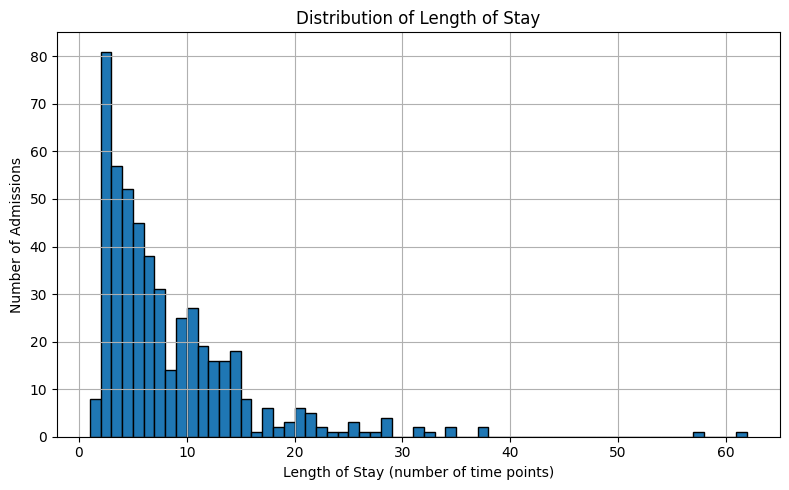

In [60]:
# Compute LOS per admission
los_per_admission = NC.groupby('admission_id')['t0'].max() + 1  # +1 since t0 starts at 0

# Plot histogram
plt.figure(figsize=(8, 5))
los_per_admission.hist(bins=range(1, los_per_admission.max() + 2), edgecolor='black')
plt.xlabel("Length of Stay (number of time points)")
plt.ylabel("Number of Admissions")
plt.title("Distribution of Length of Stay")
plt.grid(True)
plt.tight_layout()
plt.savefig("los_NC.pdf")
plt.show()

In [61]:
los_per_admission = DS.groupby('admission_id')['t0'].max() + 1

NameError: name 'DS' is not defined

In [ ]:
# Compute LOS (number of time points) per admission
los_per_admission = DS.groupby('admission_id')['t0'].max() + 1  # +1 since t0 starts at 0

# Plot histogram
plt.figure(figsize=(8, 5))
los_per_admission.hist(bins=range(1, los_per_admission.max() + 2), edgecolor='black')
plt.xlabel("Length of Stay (number of time points)")
plt.ylabel("Number of Admissions")
plt.title("Distribution of Length of Stay")
plt.grid(True)
plt.tight_layout()
plt.savefig("los_mimic.pdf")
plt.show()

In [ ]:
DS = g.summary_dict['sim_data']['Discharge safe']
#DR = g.summary_dict['sim_data']['Discharge risky']
#DD = g.summary_dict['sim_data']['Discharge dangerous']

In [ ]:
DS

In [ ]:
# Compute LOS
los_ds = DS.groupby('admission_id')['t0'].max() + 1
#los_dr = DR.groupby('admission_id')['t0'].max() + 1
#los_dd = DD.groupby('admission_id')['t0'].max() + 1

# Create vertically stacked subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)

# Plot for DS
axs[0].hist(los_ds, bins=range(1, 200), edgecolor='black', color='skyblue')
axs[0].set_title('LOS Distribution: DS')
axs[0].set_xlabel('Length of Stay (number of time points)')
axs[0].set_ylabel('Number of Admissions')
axs[0].grid(True)

# Plot for DR
axs[1].hist(los_dr, bins=range(1, 200), edgecolor='black', color='salmon')
axs[1].set_title('LOS Distribution: DR')
axs[1].set_xlabel('Length of Stay (number of time points)')
axs[1].set_ylabel('Number of Admissions')
axs[1].grid(True)

# Plot for DD
axs[2].hist(los_dd, bins=range(1, 200), edgecolor='black', color='salmon')
axs[2].set_title('LOS Distribution: DD')
axs[2].set_xlabel('Length of Stay (number of time points)')
axs[2].set_ylabel('Number of Admissions')
axs[2].grid(True)

# Final layout
plt.tight_layout()
plt.savefig("los_comp.pdf")
plt.show()


# Inspect percentage of in-icu death

In [ ]:
(
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

In [ ]:
last_rows = (
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
((last_rows['A'] == 0) & (last_rows['Py'] == 1)).mean()

In [ ]:
last_rows = (
    DS.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
((last_rows['A'] == 0) & (last_rows['Py'] == 1)).mean()

In [ ]:
NC.A

In [ ]:
(
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

# Mean Y per LOS

In [ ]:
# Step 1: Get the last row for each admission (i.e., end of follow-up)
last_rows = mimicdata.sort_values("t0").groupby("admission_id").tail(1)

# Step 2: Calculate LOS for each admission
last_rows["los"] = mimicdata.groupby("admission_id")["t0"].nunique().values

# Step 3: Group by LOS and compute mean Y
mean_y_per_los = last_rows.groupby("los")["Y"].mean().reset_index()

# Step 4: Display
print(mean_y_per_los)


In [ ]:
mean_y_per_los.Y.mean()

In [ ]:
IPW = g.summary_dict['IP_weights']

In [ ]:
NC

# Distribution of GCS when A=1

In [ ]:
DI = g.summary_dict['sim_data']['Discharge extremely dangerous']

In [ ]:
DI

In [ ]:
# Filter data where A == 1
subset = DI[DI['A'] == 1]

# Plot distribution of X
plt.figure(figsize=(8, 5))
subset['glasgow_coma_scale_total__last__last_12h'].hist(bins=30, edgecolor='black')
plt.xlabel("L values (when A=1)")
plt.ylabel("Frequency")
plt.title("Distribution of X for A=1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Filter data where A == 1
subset = NC[NC['A'] == 1]

# Plot distribution of X
plt.figure(figsize=(8, 5))
subset['glasgow_coma_scale_total__last__last_12h'].hist(bins=30, edgecolor='black')
plt.xlabel("L values (when A=1)")
plt.ylabel("Frequency")
plt.title("Distribution of X for A=1")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
NC

In [ ]:
# Filter rows where A == 1
subset = DI[DI['A'] == 1]

# Loop through each variable in L
for var in picked_for_L:
    print(f"\n--- Variable: {var} ---")
    
    if pd.api.types.is_numeric_dtype(subset[var]):
        # For continuous variable: show min, max, mean
        print("Type: Continuous")
        print("Min:", subset[var].min())
        print("Max:", subset[var].max())
        print("Mean:", round(subset[var].mean(), 2))
    else:
        # For categorical variable: show value counts
        print("Type: Categorical")
        print(subset[var].value_counts(dropna=False))


# Discharge safe analysis

In [ ]:
DS_filtered = DS.loc[
    ~DS["admission_id"].isin(
        DS.loc[(DS["t0"] == 179) & (DS["A"] == 1), "admission_id"]
    )
].copy()


In [ ]:
(
    DS.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Py']
             .mean()
)

In [ ]:
result = (
    DS.loc[(DS["t0"] > 170) & (DS["A"] == 1)]
      .groupby("t0")["admission_id"]
      .nunique()
      .sort_values(ascending=False)
)

result


# Sanity checks

In [ ]:
mimicdata = mimicdata.rename(columns={'Y': 'Y_hat'})

In [ ]:
NC = g.summary_dict['sim_data']['Natural course']
D3 = g.summary_dict['sim_data']['Discharge 5th day']
#DS = g.summary_dict['sim_data']['Discharge Knight']

In [ ]:
def last_rows(df, id_col="admission_id", time_col="t0"):
    """
    Return the last row per id_col, defined by max(time_col).
    If ties exist, takes the last one after sorting.
    """
    out = (df.sort_values([id_col, time_col])
             .groupby(id_col, as_index=False)
             .tail(1)
             .reset_index(drop=True))
    return out

# In-ICU deaths

In [ ]:
mimic_D = (
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['D']
             .mean()
)

last_rows = (
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
NC_D = ((last_rows['A'] == 0) & (last_rows['Y_hat'] == 1)).mean()

In [ ]:



last_rows = (
    D3.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
D3_D = ((last_rows['A'] == 0) & (last_rows['Py'] == 1)).mean()


last_rows = (
    DS.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
DS_D = ((last_rows['A'] == 0) & (last_rows['Py'] == 1)).mean()

In [ ]:
round(mimic_D, 3), round(NC_D, 3)

In [ ]:
(round(mimic_D, 3), round(NC_D, 3), round(D3_D, 3), round(DS_D, 3)) 

# Post-discharge deaths

In [ ]:
mimic_Z = (
    mimicdata.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)['Z']
             .mean()
)

last_rows = (
    NC.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
NC_Z = ((last_rows['A'] == 1) & (last_rows['Y_hat'] == 1)).mean()


In [ ]:



last_rows = (
    D3.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
D3_Z = ((last_rows['A'] == 1) & (last_rows['Py'] == 1)).mean()


last_rows = (
    DS.sort_values(['admission_id','t0'])
             .groupby('admission_id')
             .tail(1)
)
DS_Z = ((last_rows['A'] == 1) & (last_rows['Py'] == 1)).mean()

In [ ]:
(round(mimic_Z, 3), round(NC_Z, 3))

In [ ]:
(round(mimic_Z, 3), round(NC_Z, 3), round(D3_Z, 3), round(DS_Z, 5)) 

In [ ]:
simdata = NC.copy()

# Comparison of covariate distributions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# -----------------------------
# Helper: last row per admission
# -----------------------------
def last_rows(df, id_col="admission_id", time_col="t0"):
    return (df.sort_values([id_col, time_col])
              .groupby(id_col)
              .tail(1)
              .reset_index(drop=True))

# -----------------------------
# Ax-level plotting helpers
# -----------------------------
def ax_numeric_overlay(ax, m_vals, s_vals, name, bins=30):
    m_vals = pd.to_numeric(pd.Series(m_vals), errors="coerce").dropna().values
    s_vals = pd.to_numeric(pd.Series(s_vals), errors="coerce").dropna().values
    if len(m_vals) == 0 or len(s_vals) == 0:
        ax.set_visible(False)
        return None

    h1 = ax.hist(m_vals, bins=bins, density=True, alpha=0.5, label="mimic-iv")
    h2 = ax.hist(s_vals, bins=bins, density=True, alpha=0.5, label="natural course")
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    return ax.get_legend_handles_labels()

def ax_categorical_bars(ax, m_ser, s_ser, name, top_k=15):
    m_ser = pd.Series(m_ser).astype("object")
    s_ser = pd.Series(s_ser).astype("object")

    m_p = m_ser.value_counts(normalize=True, dropna=False)
    s_p = s_ser.value_counts(normalize=True, dropna=False)

    cats = list((m_p.add(s_p, fill_value=0))
                .sort_values(ascending=False)
                .head(top_k)
                .index)

    if len(cats) == 0:
        ax.set_visible(False)
        return None

    m_vals = [m_p.get(c, 0.0) for c in cats]
    s_vals = [s_p.get(c, 0.0) for c in cats]

    x = np.arange(len(cats))
    width = 0.4

    b1 = ax.bar(x - width/2, m_vals, width, label="mimic-iv")
    b2 = ax.bar(x + width/2, s_vals, width, label="natural course")

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats], rotation=45, ha="right", fontsize=7)
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    return ax.get_legend_handles_labels()

# -----------------------------
# Prepare data
# -----------------------------
m_last = last_rows(mimicdata)
s_last = last_rows(simdata)

# -----------------------------
# Define covariates
# -----------------------------
numeric_covariates = list(picked_L)

categorical_covariates = [
    "vent_mode__last__last_12h"
]

# -----------------------------
# Subgroup: in-ICU death only
# (Assumes D=1 indicates in-ICU death; keep A=0 to exclude discharged)
# -----------------------------
mask_m = (m_last["A"] == 1) & (m_last["Z"] == 1)
mask_s = (s_last["A"] == 1) & (s_last["Z_hat"] == 1)

m_sub = m_last.loc[mask_m]
s_sub = s_last.loc[mask_s]

print(f"IN-ICU death subgroup | mimic n={len(m_sub)} | sim n={len(s_sub)}")

# -----------------------------
# Build plot list in left-to-right order
# -----------------------------
plot_specs = []
for var in numeric_covariates:
    if var in m_sub.columns and var in s_sub.columns:
        plot_specs.append(("num", var))

for var in categorical_covariates:
    if var in m_sub.columns and var in s_sub.columns:
        plot_specs.append(("cat", var))

k = len(plot_specs)
if k == 0:
    raise ValueError("No covariates found in both datasets for the selected subgroup.")

# -----------------------------
# Grid layout (left-to-right)
# -----------------------------
ncols = 3
nrows = ceil(k / ncols)

fig_w = 5.2 * ncols
fig_h = 3.6 * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), dpi=200, constrained_layout=True)
axes = np.array(axes).reshape(-1)

legend_handles = None
legend_labels = None

for i, (kind, var) in enumerate(plot_specs):
    ax = axes[i]
    if kind == "num":
        out = ax_numeric_overlay(
            ax,
            m_sub[var],
            s_sub[var],
            name=f"{var}"
        )
    else:
        out = ax_categorical_bars(
            ax,
            m_sub[var],
            s_sub[var],
            name=f"{var}"
        )

    # Capture legend handles once for a global legend
    if out is not None and legend_handles is None:
        legend_handles, legend_labels = out

# Hide unused axes
for j in range(k, len(axes)):
    axes[j].set_visible(False)

# Global title + global legend
fig.suptitle("Covariate distribution comparison at in-ICU death (last row per admission)", fontsize=12)

if legend_handles is not None:
    fig.legend(
        legend_handles, legend_labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

plt.show()


Time point 0
Time point 1
Time point 0
Time point 1
Time point 2
Time point 3
Time point 4
Time point 5
Time point 6
Time point 7
Time point 8
Time point 9
Time point 10
Time point 11
Time point 12
Time point 13
Time point 14
Time point 15
Time point 16
Time point 17
Time point 18
Time point 19
Time point 20
Time point 21
Time point 22
Time point 23
Time point 24
Time point 25
Time point 26
Time point 27
Time point 28
Time point 29
Time point 30
Time point 31
Time point 32
Time point 33
Time point 34
Time point 35
Time point 36
Time point 37
Time point 38
Time point 39
Time point 40
Time point 41
Time point 42
Time point 43
Time point 44
Time point 45
Time point 46
Time point 47
Time point 48
Time point 49
Time point 50
Time point 51
Time point 52
Time point 53
Time point 54
Time point 55
Time point 56
Time point 57
Time point 58
Time point 59
Time point 60


# SMD plots